# Propagation of Hole waveguide (Antiguide)

Empty hole in glass. N0 configuration in Bird


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from slab import SlabExact, plotlogf
from scipy.optimize import newton
from scipy.integrate import quad
from IPython.display import Video, HTML

import json

plt.style.use('dark_background')
%matplotlib widget

In [2]:
A = SlabExact(scale=1e-6, Ts=[2., 2., 2.], xrefs=[300, 500, 300],
              ns=[1.44, 1, 1.44], wl=1e-6, symmetric=True)


In [6]:
w = .5
s = 0
amp = 2.5

Lx = -w + s
Rx = w + s

def quadratic_piecewise(x):
    conds = [(x<Lx), ((Lx<=x)*(x<=Rx)), (x>Rx)]
    funcs = [0, lambda x: amp * (1 - ((x-s)/w)**2), 0]
    return np.piecewise(x, conds, funcs)

def uneven_cubic(x):
    conds = [(x<-.5), ((-.5<=x)*(x<=.5)), (x>.5)]
    funcs = [0, lambda x: 5*(x+.1)*(.25-x**2), 0]
    return np.piecewise(x, conds, funcs)
    
def modified_dist(x):
    return (x-1/4) * np.exp(-(x-1/2)**2)  

def odd_modified_dist(x):
    return x * np.exp(-x**2)
    
def normal_dist(x):
    return np.exp(-x**2)

In [7]:
# Set input function
f0 = quadratic_piecewise
f0_shifted = lambda x: f0(x) + 1
# Set input field type
field_type = 'TE'

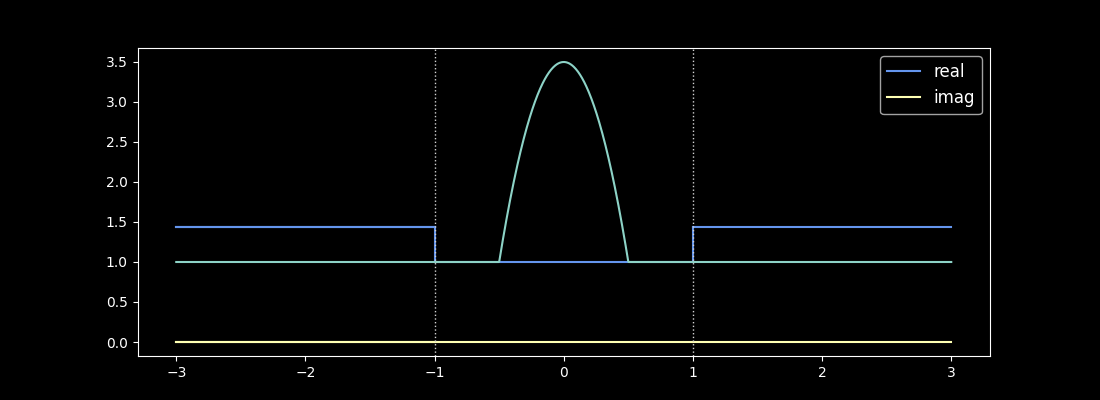

In [8]:
A.plot_refractive_index()
A.add_1d_plot(f0_shifted)

# Check for guided modes

Doesn't seem like it should have any

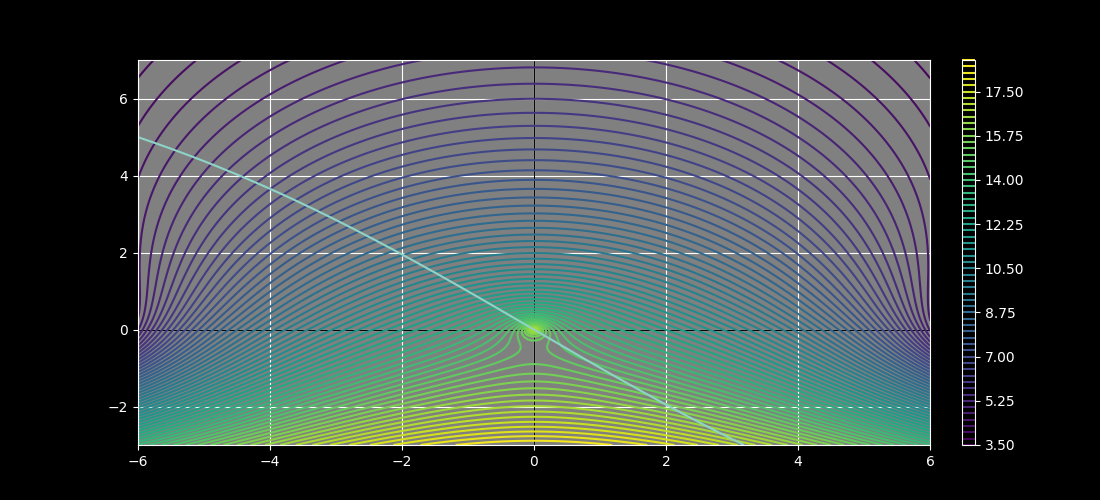

In [9]:
A.determinant_plot(-6, 6, -3, 7);

No guided modes.

## Leaky Modes

In [10]:
leaky_bdry = A.Zi_from_Beta(A.K0 * A.n_low)

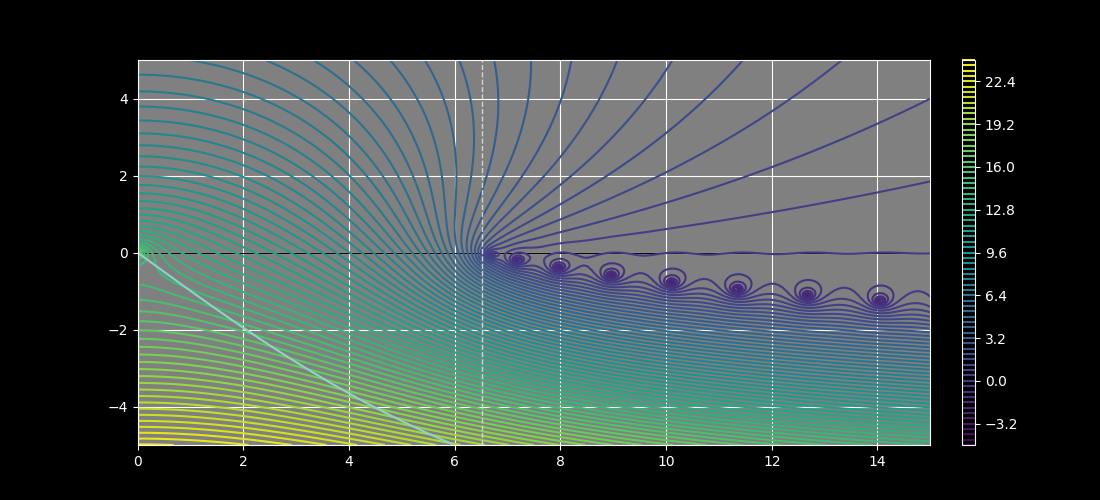

In [13]:
A.determinant_plot(0, 15, -5, 5);
plt.vlines(leaky_bdry.real, *plt.gca().get_ylim(), color='lightgray', lw=1, ls="--");

In [14]:
Z0 = newton(A.determinant, np.array(1.01*A.K_low+.05j))
print(Z0)
A.plot_points(Z0)

[6.68512884-0.05373814j]


In [15]:
FsZ = A.fields(Z0)

In [16]:
xs = np.linspace(-10, 10, 600)

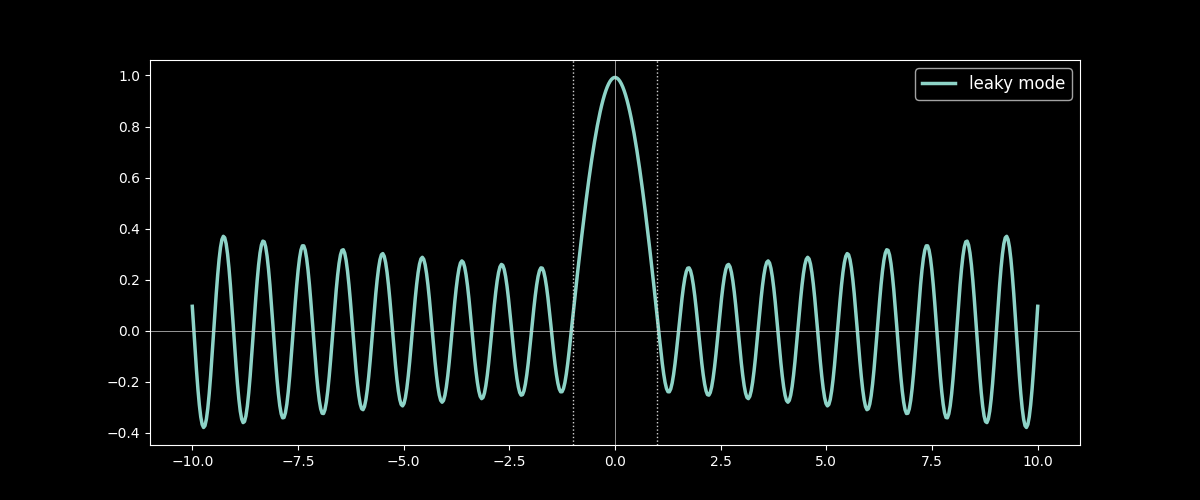

In [17]:
A.plot_field_1d(FsZ, xs=xs, linewidth=2.5, label='leaky mode');

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

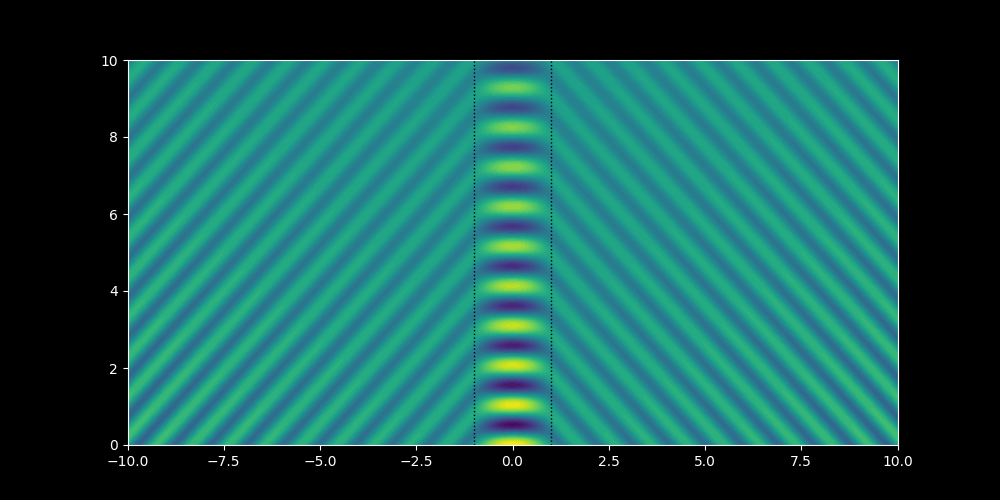

In [18]:
A.plot_field_2d(FsZ, xs=xs, zmin=0, zmax=10, zref=500, colorbar=False, figsize=(10,5))
# plt.axis('equal');

# Propagation of input



In [19]:
A.Z_evanescent

np.float64(9.047786842338605)

In [97]:
Propagator_Class = A.propagator()
Normalizer = A.normalizer('eigvec')

In [121]:
contour = A.real_contour(0.012, 6.2, 200)
# contour = A.sdp_contour(0.012, 6.2, 400)

P1e = Propagator_Class(contour,
                       f0=f0, Lx=-.5, Rx=.5,
                       sign=1, Normalizer=Normalizer)
P1o = Propagator_Class(contour,
                       f0=f0, Lx=-.5, Rx=.5,
                       sign=-1, Normalizer=Normalizer)

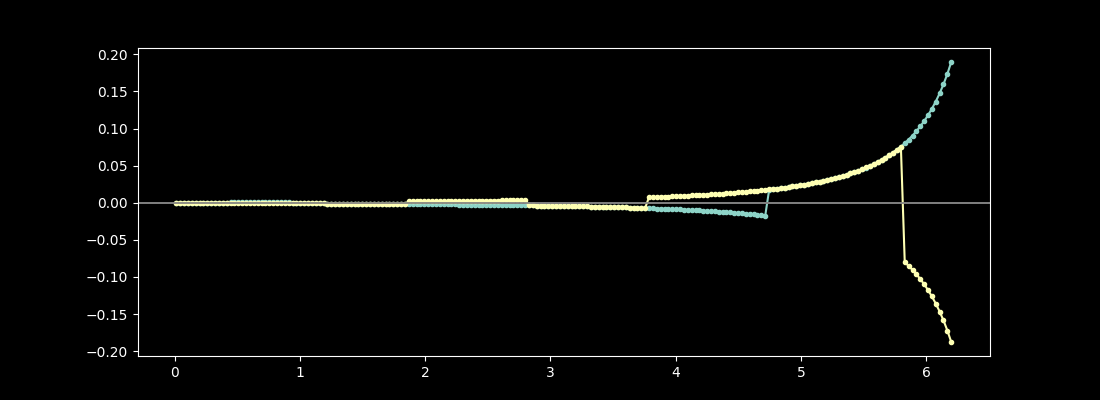

In [122]:
## plt.close('all')
P1e.plot_transform(part='real')
P1o.plot_transform(ax=plt.gca());

In [125]:
contour = A.real_contour(6.2, 7, 150)

P2e = Propagator_Class(contour,
                       f0=f0, Lx=-.5, Rx=.5,
                       sign=1, Normalizer=Normalizer)
P2o = Propagator_Class(contour,
                       f0=f0, Lx=-.5, Rx=.5,
                       sign=-1, Normalizer=Normalizer)

(<Figure size 1100x400 with 1 Axes>, <Axes: >)

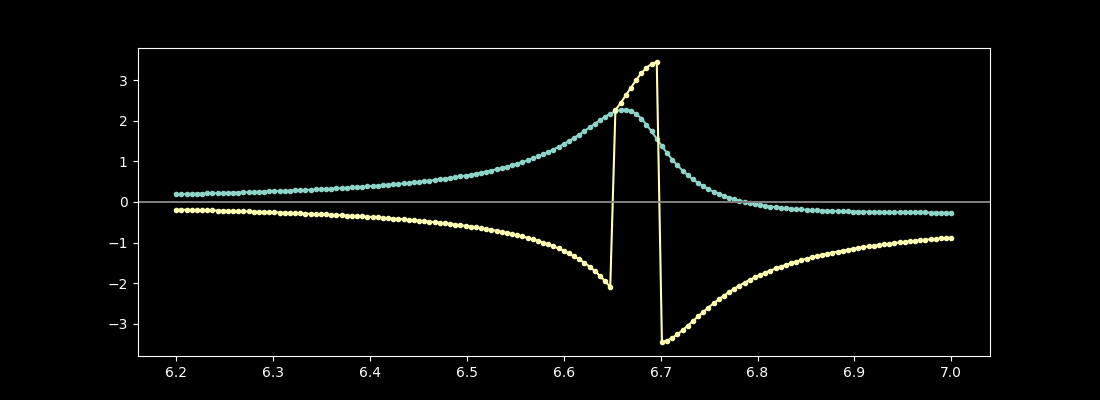

In [126]:
## plt.close('all')
P2e.plot_transform(part='real')
P2o.plot_transform(ax=plt.gca())

In [131]:
contour = A.real_contour(7, A.Z_evanescent, 150)

P3e = Propagator_Class(contour,
                       f0=f0, Lx=-.5, Rx=.5,
                       sign=1, Normalizer=Normalizer)
P3o = Propagator_Class(contour,
                       f0=f0, Lx=-.5, Rx=.5,
                       sign=-1, Normalizer=Normalizer)

(<Figure size 1100x400 with 1 Axes>, <Axes: >)

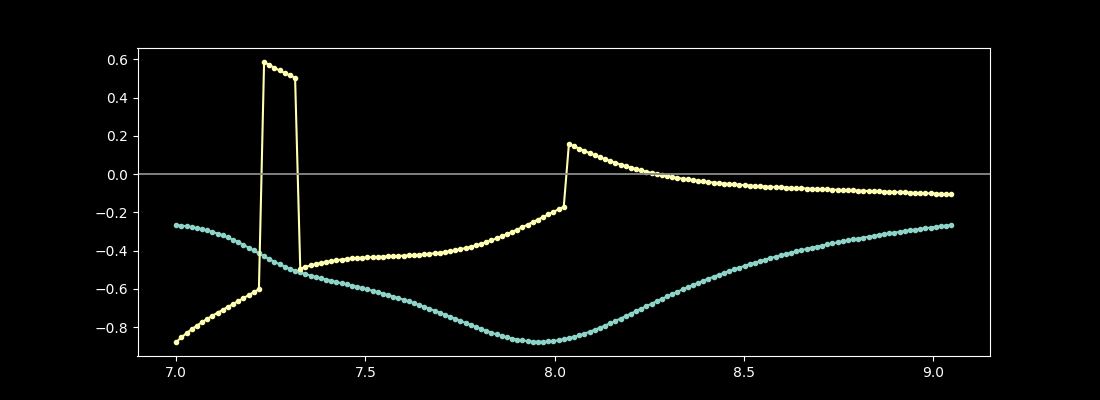

In [132]:
## plt.close('all')
P3e.plot_transform(part='real')
P3o.plot_transform(ax=plt.gca())

In [133]:
contour = A.real_contour(A.Z_evanescent, 25, 200)

P4e = Propagator_Class(contour, f0=f0, Lx=-.5, Rx=.5,
                       sign=1, Normalizer=Normalizer)
P4o = Propagator_Class(contour, f0=f0, Lx=-.5, Rx=.5,
                       sign=-1, Normalizer=Normalizer)

(<Figure size 1100x400 with 1 Axes>, <Axes: >)

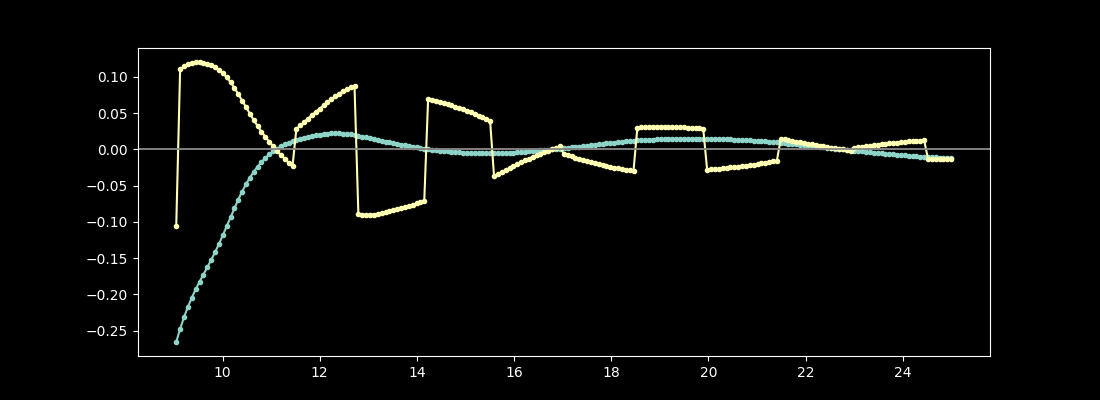

In [134]:
## plt.close('all')
P4e.plot_transform(part='real')
P4o.plot_transform(ax=plt.gca())

### Combine propagators into one function

In [175]:
Props = [P1e,
      P1o,
      P2e,
      P2o,
      P3e,
      P3o,
     ]

Evs = [P4e,
      P4o,
     ]

x0 = 0
z0 = 0

prop_x = lambda x: sum([P.slice_propagate(x, constant_variable='z', slice_at=z0) for P in Props])
prop_z = lambda z: sum([P.slice_propagate(z, constant_variable='x', slice_at=x0) for P in Props])
Prop = lambda x, z: sum([P.propagate(x, z) for P in Props])

ev_x = lambda x: sum([P.slice_propagate(x, constant_variable='z', slice_at=z0) for P in Evs])
ev_z = lambda z: sum([P.slice_propagate(z, constant_variable='x', slice_at=x0) for P in Evs])
Ev = lambda x, z: sum([P.propagate(x, z) for P in Evs])

rad_x = lambda x: prop_x(x) + ev_x(x)
rad_z = lambda z: prop_z(z) + ev_z(z)
Rad = lambda x, z: Prop(x,z) + Ev(x,z)

full_x = rad_x
full_z = rad_z
Full = Rad

diff_x = lambda x: full_x(x) - f0(x)

# 1D Plot


In [176]:
xs = np.linspace(-6, 6, 1000)


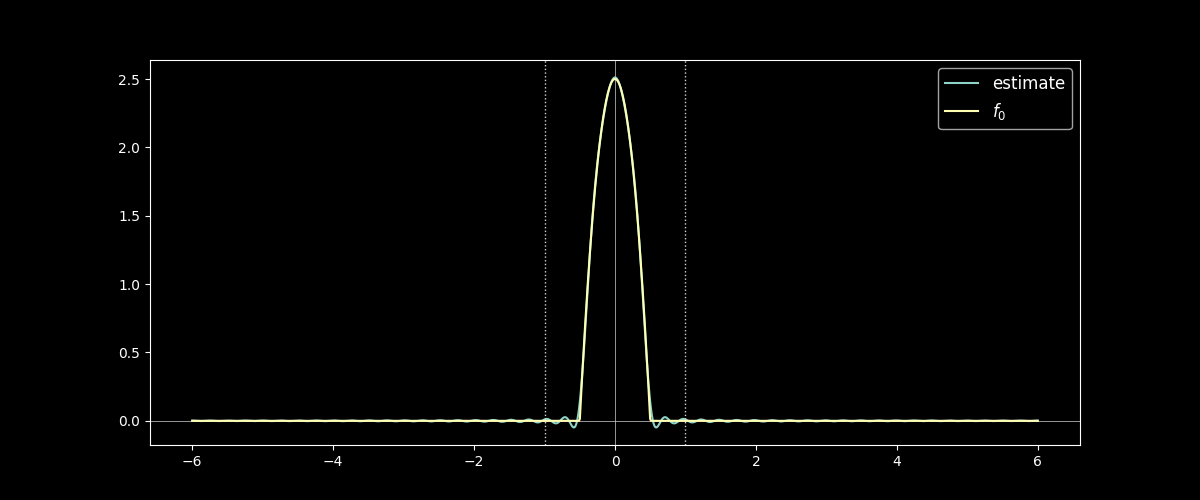

In [177]:
A.plot_field_1d(full_x, xs=xs, label='estimate');
A.add_1d_plot(f0, xs=xs, label='$f_0$')

## Slice along Z axis

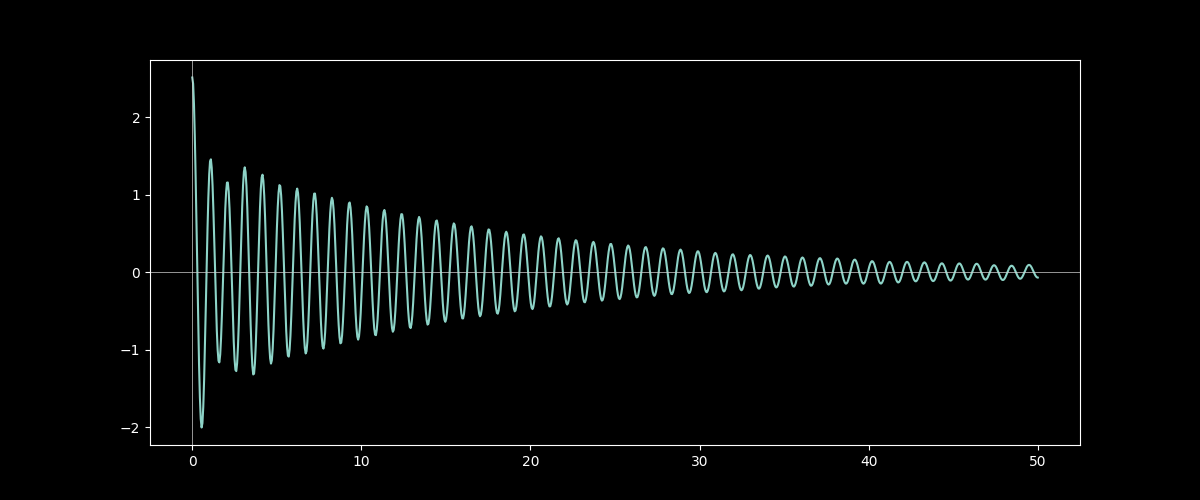

In [185]:
A.plot_field_1d(full_z, xs=np.linspace(0, 50, 1000), plot_Rhos=False);


## 2D Plots

In [186]:
xs = np.concatenate([np.linspace(-10,-1, 100), 
                     np.linspace(-1, 1, 50), 
                     np.linspace(1, 10, 100)])

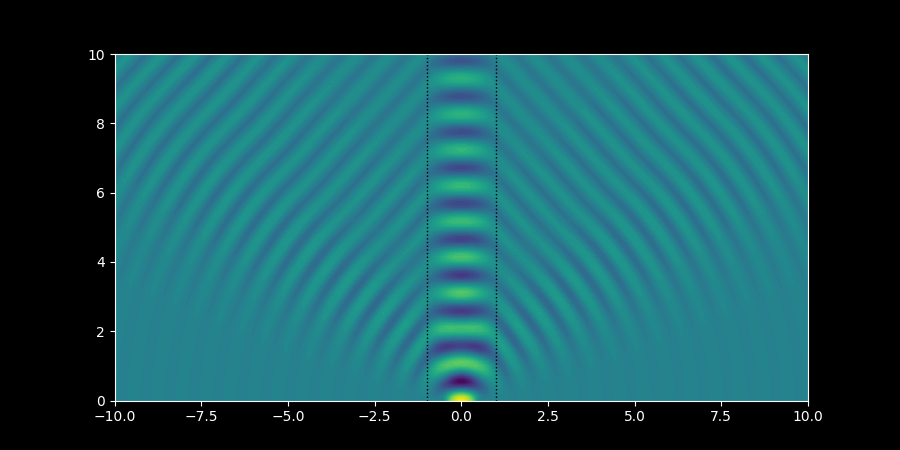

In [187]:
A.plot_field_2d(Full, xs=xs, zs=np.linspace(0, 10, 100), colorbar=False, levels=60);


In [188]:
# A.plot_field_2d_surface(Full, xs=xs, colorbar=False, zoom=3.5,
#                         azim=-47, elev=30, 
#                         zmax=10, zref=150,
#                         rstride=1, cstride=1);

# Comparison to leaky mode representation

In [151]:
# If using eigvec normalization, only need to do this for leaky field
# if not, need to perform circular contour integral around leaky-mode Z value.
coeff = quad(lambda x: FsZ(x)[0] * f0(x), Lx, Rx, complex_func=True)[0]

leaky_x = lambda x: coeff * FsZ(x)
leaky_z = lambda z: coeff * FsZ(0, z)
Leaky = lambda x, z: coeff * FsZ(x, z)

Diff = lambda x, z: Leaky(x,z) - Full(x,z)

## Asymptotics of true and leaky mode in direction of propagation

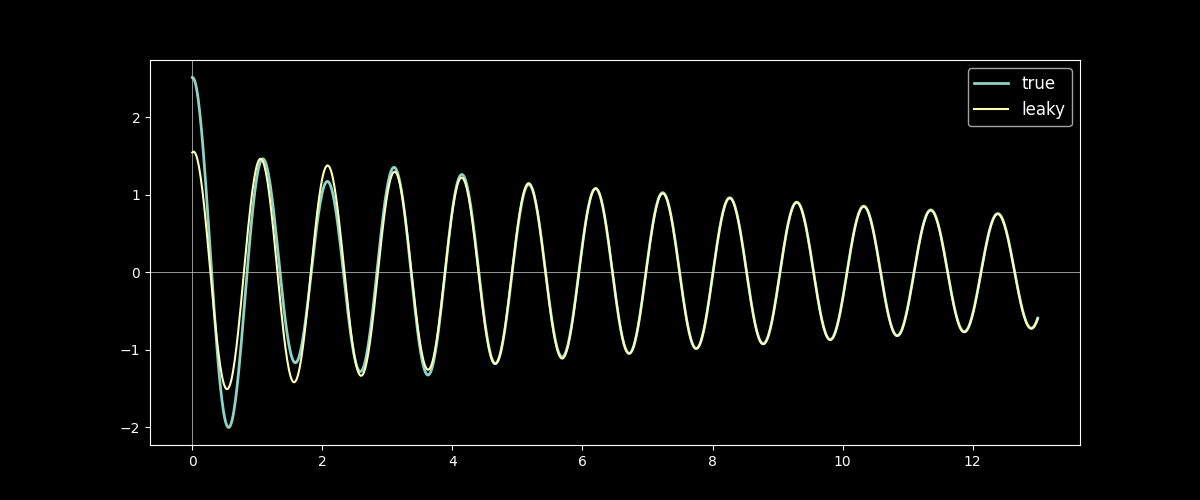

In [146]:
part='real'
A.plot_field_1d(full_z, xs=np.linspace(0, 13, 1000), part=part, plot_Rhos=False, linewidth=2, label='true');
A.add_1d_plot(leaky_z, xs=np.linspace(0, 13, 1000), part=part, label='leaky');


### 2d Plots of real field and leaky mode field

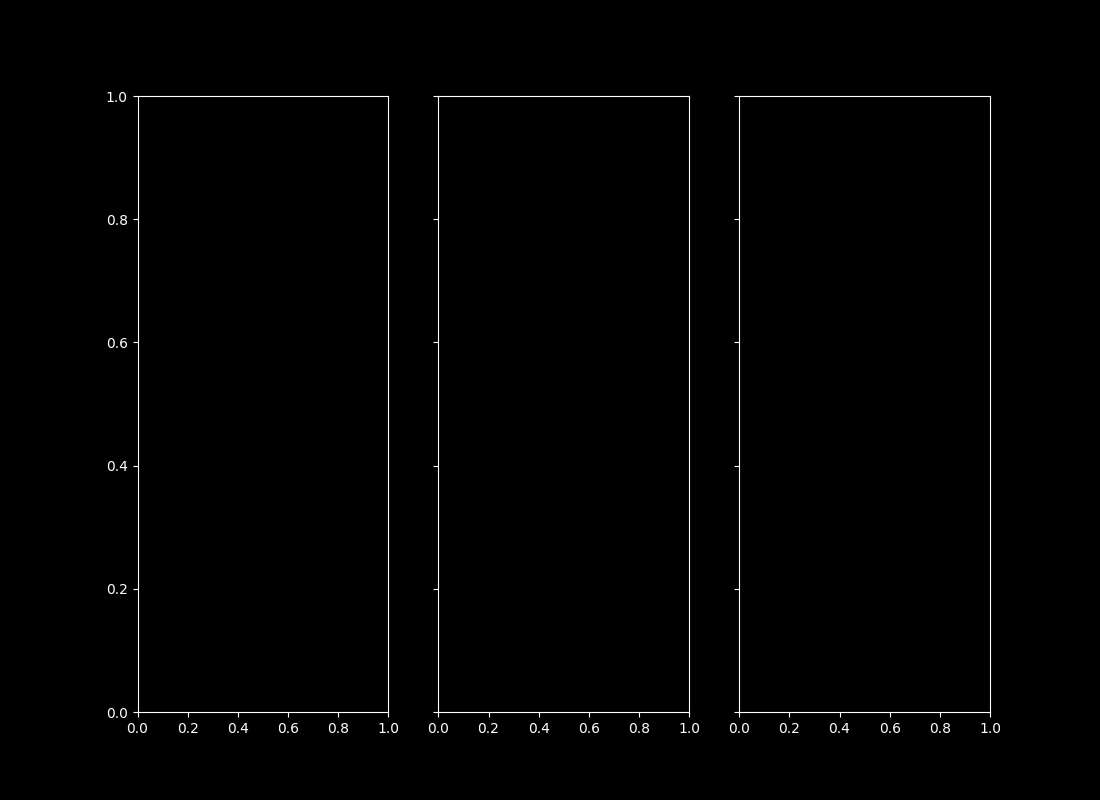

In [203]:
plt.close('all')
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(11,8))

xs = np.linspace(-5, 5, 100)

zmin = 0
zmax = 25
zref = int((zmax-zmin)*20/2)
zs = np.linspace(zmin, zmax, zref)

In [204]:
# fig, ax = A.plot_field_2d(Full, xs=, zmin=0, zmax=20, zref=200);
A.add_2d_plot(Full, ax=ax1, xs=xs, zs=zs, plot_Rhos=True, colorbar=True);
ax1.set_title('True Field')

Text(0.5, 1.0, 'True Field')

In [205]:
A.add_2d_plot(Leaky, ax=ax2, xs=xs, zs=zs, plot_Rhos=True, colorbar=True);
ax2.set_title('Leaky Mode Field')

Text(0.5, 1.0, 'Leaky Mode Field')

In [206]:
A.add_2d_plot(Diff, ax=ax3, xs=xs, zs=zs, plot_Rhos=True, part='norm', colorbar=True);
ax3.set_title('Norm of Difference')

Text(0.5, 1.0, 'Norm of Difference')

## Animations

### Transverse field at input

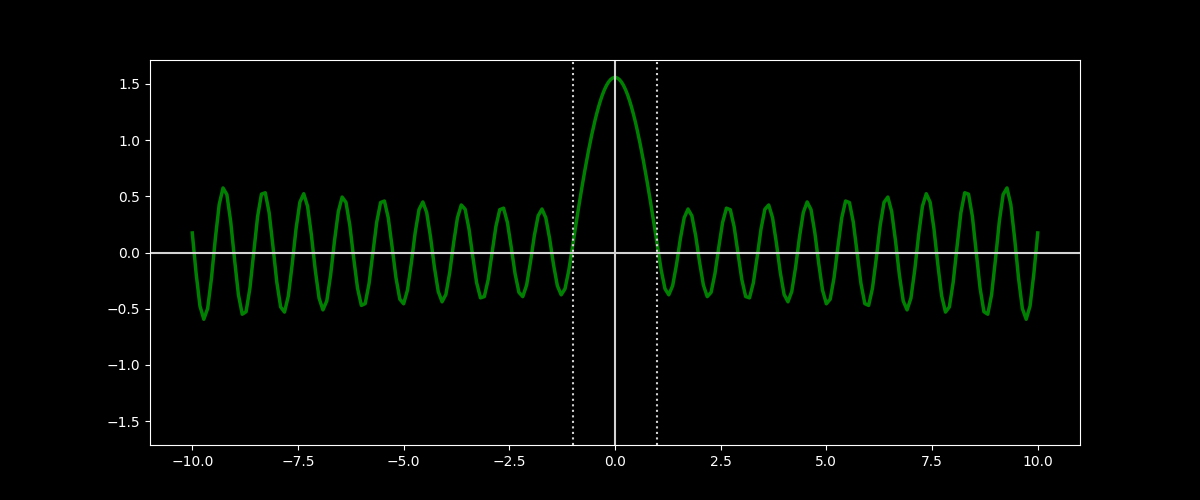

In [156]:
A.animate_field_1d(leaky_x, 'leaky', xs=xs, linewidth=2.5, secs=2, fps=32, color='g')

In [157]:
Video('leaky.mp4', html_attributes="controls loop")


#### Full field

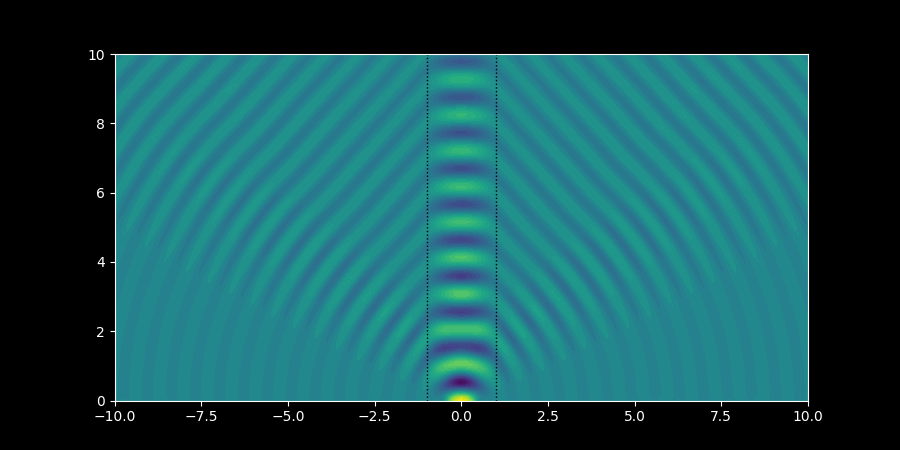

In [165]:
A.animate_field_2d(Full, 'true_field_2d_animation', xs=xs, zs=np.linspace(0,10,100), secs=2, fps=22)

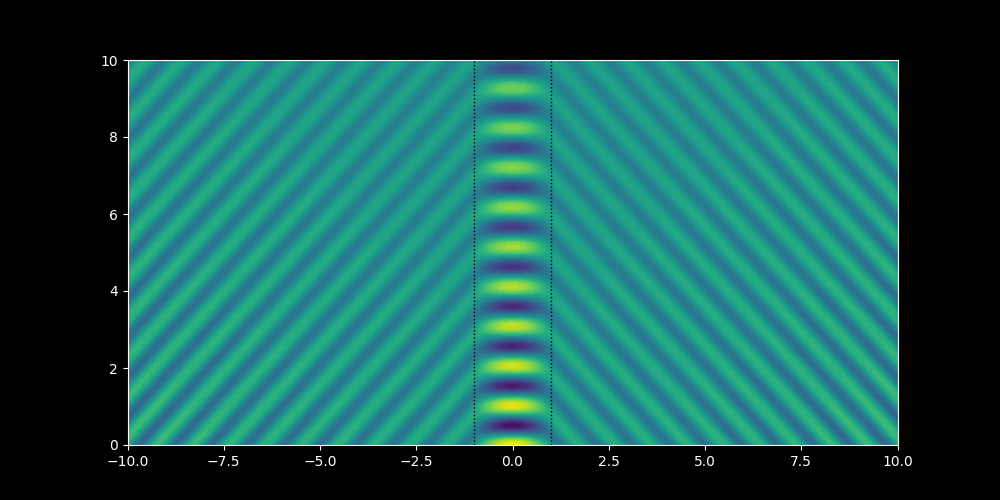

In [168]:
A.animate_field_2d(Leaky, 'leaky_mode_antiguide_contour',xs=xs, zs=np.linspace(0,10,300),
                   figsize=(10,5), secs=2, fps=22)

In [167]:
Video('true_field_2d_animation.mp4', html_attributes="controls loop autoplay")


In [169]:
Video('leaky_mode_antiguide_contour.mp4', html_attributes="controls loop autoplay")


#### Animated surface plot

In [211]:
# Slow animation cell

# A.animate_field_2d_surface(Full_leaky_theirs, 'leaky_field_3d_animation', fps=20, secs=2,  xs=np.linspace(-6,6,200), zmin=0, zmax=10, zref=220,
#                            rstride=1, cstride=1, part='real', color_min=-.2, color_max=.2, azim=-47, elev=30, zoom=3.5, dpi=300)

In [215]:
# HTML("""
# <video controls id="theVideo3"> <source src="true_field_3d_animation.mp4"> </video>
# <video controls id="theVideo4"> <source src="leaky_field_3d_animation.mp4"> </video>
# <script> video3 = document.getElementById("theVideo3")
# video4 = document.getElementById("theVideo4")
# video3.width = 650; video3.playbackRate = 1; video3.loop = true; video3.autoplay = true;
# video4.width = 650; video4.playbackRate = 1; video4.loop = true; video4.autoplay = true;
# </script> """)


In [262]:
mode_type='leaky'

paper_method = False

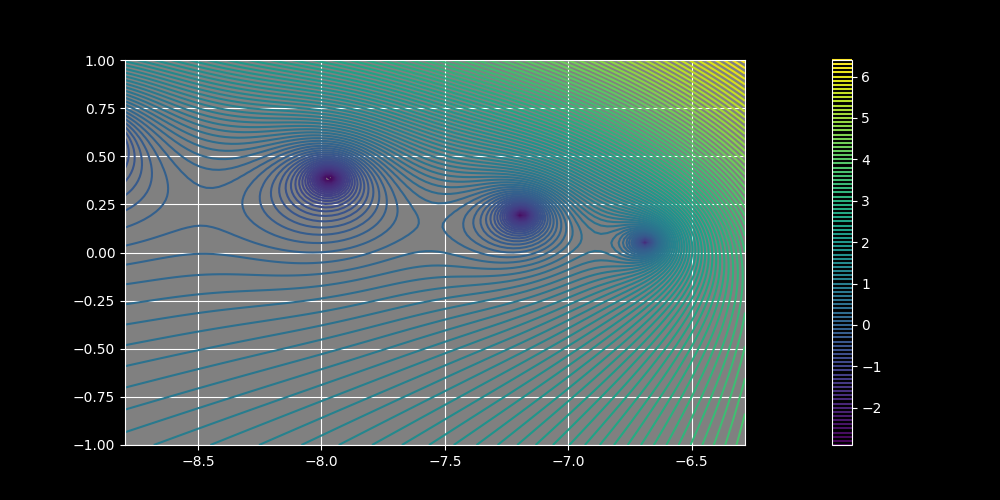

In [263]:
plotlogf(A.determinant_Z, - 1.4*A.K_low, -A.K_low, -1,1, field_type, mode_type,
         figsize=(10,5),iref=100, rref=100,levels=100)

hi kirbee ❤️

In [264]:
Z_leaky = newton(A.determinant_Z, -6.5, args=('TE', mode_type))
Z_leaky, A.determinant_Z(Z_leaky, mode_type=mode_type)
plt.plot(Z_leaky.real, Z_leaky.imag, 'ro');

In [265]:
circ_contour = {'center': Z_leaky, 'radius': 1e-4, 'N':50}

In [266]:
P_leaky_even = Propagator_Class(f0=f0, Lx=-.5, Rx=.5, 
                     LZ=100, RZ=150, NZ=10, 
                     field_type=field_type, conjugate=False,
                     sign='+1', circ_contour=circ_contour, paper_method=paper_method)
P_leaky_odd = Propagator_Class(f0=f0, Lx=-.5, Rx=.5, 
                     LZ=100, RZ=150, NZ=10, 
                     field_type=field_type, conjugate=False,
                     sign='-1', circ_contour=circ_contour, paper_method=paper_method)

 96% (48 of 50) |####################### | Elapsed Time: 0:00:00 ETA:   0:00:00

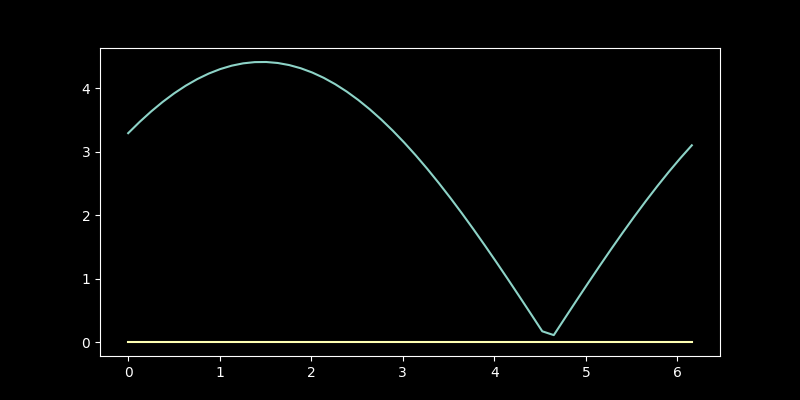

In [267]:
plt.close('all')
fig, ax = plt.subplots(1, figsize=(8,4))
ax.plot(P_leaky_even.ts,  np.abs(P_leaky_even.alphas.imag));
ax.plot(P_leaky_odd.ts,  np.abs(P_leaky_odd.alphas));

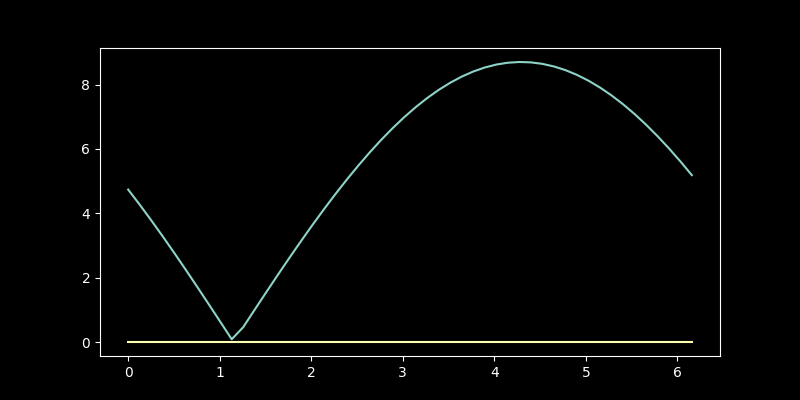

In [268]:
plt.close('all')
fig, ax = plt.subplots(1, figsize=(8,4))
ax.plot(P_leaky_even_theirs.ts,  np.abs(P_leaky_even_theirs.alphas.real));
ax.plot(P_leaky_odd_theirs.ts,  np.abs(P_leaky_odd_theirs.alphas));

In [269]:
P_ls = [P_leaky_even, P_leaky_odd]

full_leaky = lambda x : sum([P.slice_propagate(x) for P in P_ls])
Full_leaky = lambda x, z : sum([P.propagate(x, zs=z) for P in P_ls])

/home/pv/local/slab/slab.py:1499: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=legend_fontsize)


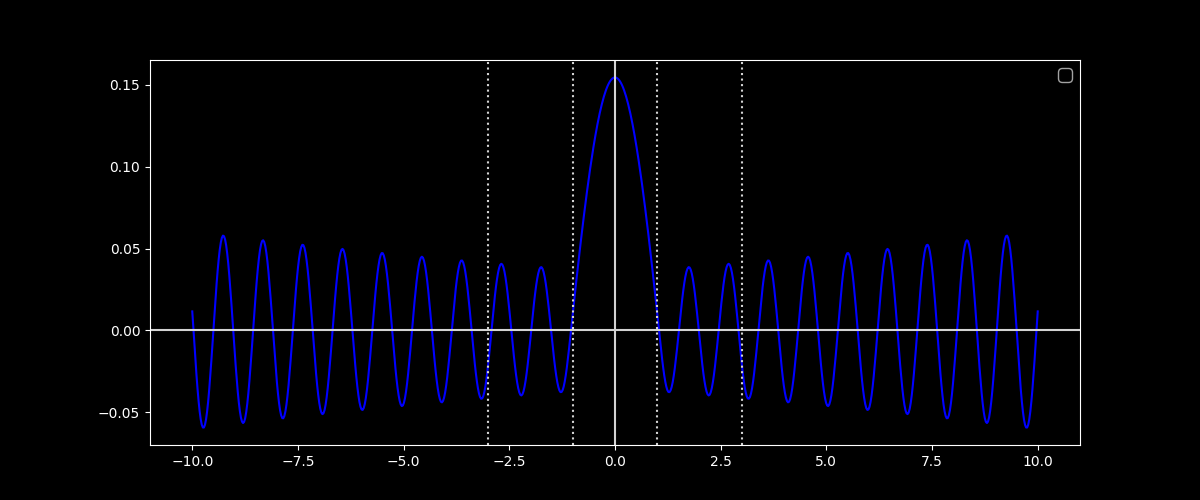

In [270]:
A.plot_field_1d(full_leaky, xs=xs, part='real', color='blue');

In [271]:
slice_at_x = 0
constant_variable = 'x'

full_z_leaky_ours = lambda z: sum([P.slice_propagate(z, slice_at=slice_at_x, constant_variable=constant_variable) for P in P_ls])
full_z = lambda z: sum([P.slice_propagate(z, slice_at=slice_at_x, constant_variable=constant_variable) for P in Ps])



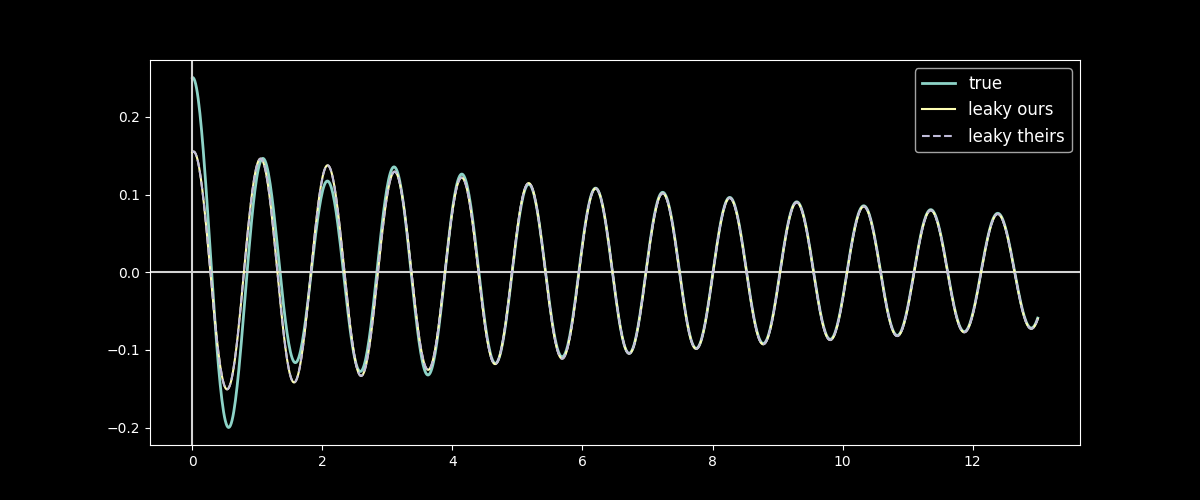

In [275]:
part = 'real'
A.plot_field_1d(full_z, xs=np.linspace(0, 13, 1000), part=part, plot_Rhos=False, linewidth=2,label='true');
A.add_1d_plot(full_z_leaky_ours, xs=np.linspace(0, 13, 1000), part=part, label='leaky ours');
A.add_1d_plot(full_z_leaky_theirs, xs=np.linspace(0, 13, 1000), part=part, linestyle='--', label='leaky theirs');


#### Issues:

- Using our method, even though there appears to be a pole in the integrand where we need it to be, when we do a circular contour integral it appears to zero out.  Everything should be right, but we get zero...  This happens for all other pole locations too: -Z, Z.conj(), -Z.conj().

- This is strange because when we do this for the delta function input everything works out: we get convergent leaky mode fields.


## Adding steepest descent path contribution

In [313]:
def sdp(x, guide=A):
    K = guide.K0 * guide.n0
    return -(K * x) / np.sqrt(K**2 + x**2)

In [330]:
xmin, xmax= -8, .5
ymin, ymax = -1, 2
xs_sdp = np.linspace(xmin, xmax, 1000)
ys_sdp = sdp(xs_sdp)
msk = np.where((ys_sdp<ymax)*(ys_sdp>ymin))

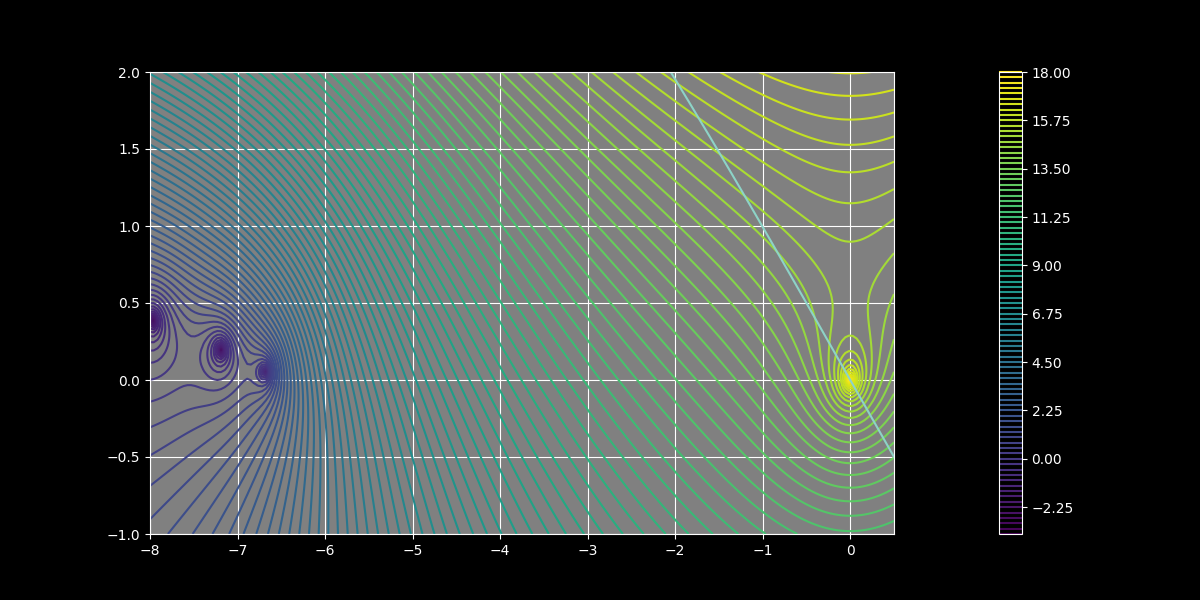

In [332]:
plotlogf(A.determinant_Z, xmin, xmax, ymin, ymax, 'TE', 'leaky', iref=200, rref=200, levels=100)
ax = plt.gca()
ax.plot(xs_sdp[msk], ys_sdp[msk]);
# ax.plot(xs[msk], -ys[msk]);

# Save data for visualization

In [216]:
# propfuncs = [P1, P2, P3]
# evfuncs = [P4, P5, P6, P7, P8]

In [179]:
# Prop = lambda x, z: sum([f.propagate(x, zs=z) for f in propfuncs])
# Ev = lambda x, z: sum([f.propagate(x, zs=z) for f in evfuncs]) 
# Full = lambda x, z: Prop(x, z) + Ev(x, z)

In [195]:
xs = np.linspace(-15, 15, 1200)
zs = np.linspace(0, 20, 600)


In [196]:
f0s = f0(xs)

In [197]:
rad_ys_propagating = Prop(xs, zs)

In [198]:
rad_ys_evanescent = Ev(xs, zs)


In [199]:
Xs, Zs = np.meshgrid(xs, zs)

In [200]:
def get_trig_indices(mesh_array):
    '''Get triangle index list for three js mesh formation via indexed buffer geometry.'''
    if len(mesh_array.shape) <= 1:
        raise ValueError('Provide meshgrid array as input.')
    Nz, Nx = mesh_array.shape[0], mesh_array.shape[1]
    l_inds = Nx * Nz
    indices =  np.arange(0, l_inds).reshape((Nx, Nz)).T  # Note transpose
    fbases = indices[:Nz-1, :Nx-1].T.flatten()  # Note transpose and index switch due to transpose
    f1 = np.array([[i, i+Nz, i+1] for i in fbases], dtype=int)
    f2 = np.array([[i+1, i+Nz, i+Nz+1] for i in fbases], dtype=int)
    return np.concatenate((f1, f2))


def get_base_vertices(Xs, Zs):
    '''Get vertices of triangles with zero height (y component in three.js).'''
    if Xs.shape != Zs.shape:
        raise ValueError('Provide meshgrid arrays (ie Xs, Zs = np.meshgrid(xs,zs)) as inputs.')
    Base = np.array([Xs, np.zeros_like(Xs), Zs], dtype=float)
    L = Xs.shape[0] * Xs.shape[1]
    base_vertices = Base.T.reshape((L,3))
    return base_vertices


def create_height_array_from_complex(ys, Xs):
    '''Get data for height from complex ys input (needs to be formatted as list:
        [ys[0].real, ys[0].imag, ys[1].real, ys[1].imag, ... ].'''
    L = Xs.shape[0] * Xs.shape[1]
    Ys = np.array([ys.real, ys.imag], dtype=float)
    heights = Ys.T.reshape((L,2))
    return heights


def save_trig_indices_as_json(filepath, mesh_array):
    indices = get_trig_indices(mesh_array)
    with open(filepath + '.json', 'w') as outfile:
        json.dump(indices.flatten().tolist(), outfile, separators=(',', ':'),
                  sort_keys=True, indent=4)


def save_base_vertices_as_json(filepath, Xs, Zs):
    base_vertices = get_base_vertices(Xs, Zs)
    with open(filepath + '.json', 'w') as outfile:
        json.dump(base_vertices.flatten().tolist(), outfile, separators=(',', ':'),
                  sort_keys=True, indent=4)
        

def save_heights_as_json(filepath, ys, Xs):
    heights= create_height_array_from_complex(ys, Xs)
    with open(filepath + '.json', 'w') as outfile:
        json.dump(heights.flatten().tolist(), outfile, separators=(',', ':'),
                  sort_keys=True, indent=4)

def save_values_as_json(filepath, f0s):
    with open(filepath + '.json', 'w') as outfile:
        json.dump(f0s.tolist(), outfile, separators=(',', ':'),
                  sort_keys=True, indent=4)




In [201]:
prefix='/home/pv/local/slab/apps/antiguide/'

In [202]:
save_trig_indices_as_json(prefix + 'trig_indices_new', Xs)


In [203]:
save_base_vertices_as_json(prefix + 'base_vertices_new', Xs, Zs)


In [204]:
save_heights_as_json(prefix + 'evanescent_heights', rad_ys_evanescent, Xs)


In [205]:
save_heights_as_json(prefix + 'propagating_heights', rad_ys_propagating, Xs)


In [206]:
save_values_as_json(prefix + 'f0s', f0s)


In [207]:
save_values_as_json(prefix + 'x0s', xs)


# Discovery of conjugation issue!

With kirbee emoticon...

### Our method

This still has issues: all the contour integrals go to zero.

In [262]:
mode_type='leaky'

paper_method = False

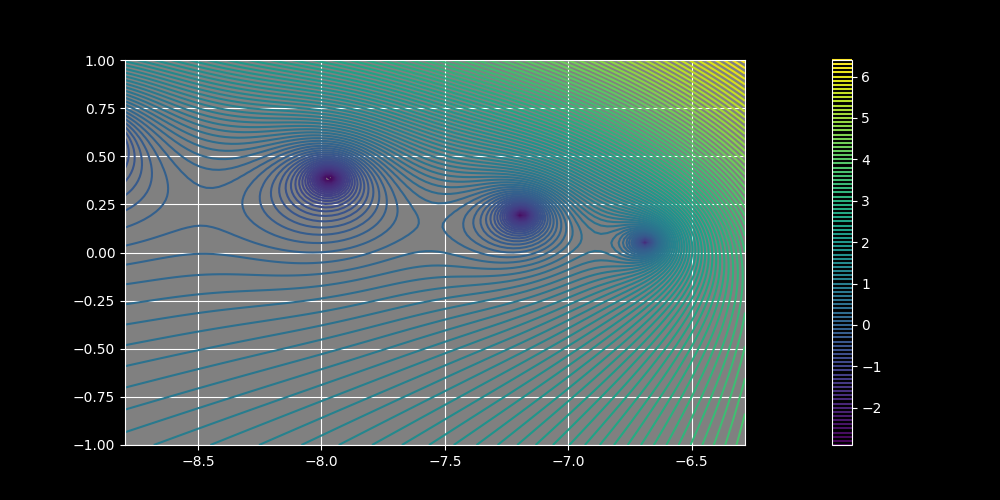

In [263]:
plotlogf(A.determinant_Z, - 1.4*A.K_low, -A.K_low, -1,1, field_type, mode_type,
         figsize=(10,5),iref=100, rref=100,levels=100)

hi kirbee ❤️

In [264]:
Z_leaky = newton(A.determinant_Z, -6.5, args=('TE', mode_type))
Z_leaky, A.determinant_Z(Z_leaky, mode_type=mode_type)
plt.plot(Z_leaky.real, Z_leaky.imag, 'ro');

In [265]:
circ_contour = {'center': Z_leaky, 'radius': 1e-4, 'N':50}

In [266]:
P_leaky_even = Propagator_Class(f0=f0, Lx=-.5, Rx=.5, 
                     LZ=100, RZ=150, NZ=10, 
                     field_type=field_type, conjugate=False,
                     sign='+1', circ_contour=circ_contour, paper_method=paper_method)
P_leaky_odd = Propagator_Class(f0=f0, Lx=-.5, Rx=.5, 
                     LZ=100, RZ=150, NZ=10, 
                     field_type=field_type, conjugate=False,
                     sign='-1', circ_contour=circ_contour, paper_method=paper_method)

 96% (48 of 50) |####################### | Elapsed Time: 0:00:00 ETA:   0:00:00

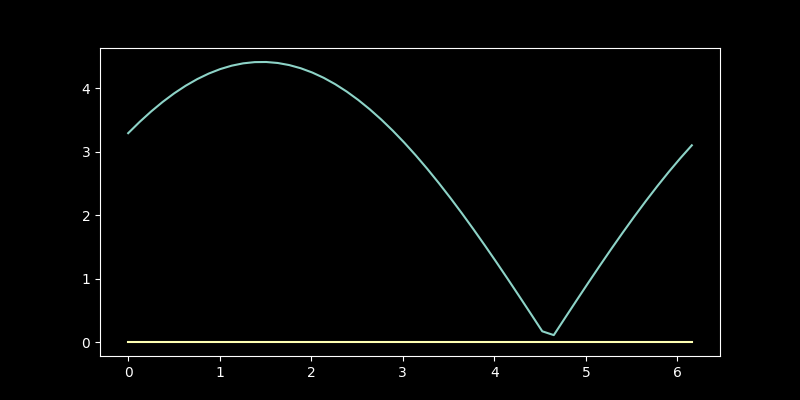

In [267]:
plt.close('all')
fig, ax = plt.subplots(1, figsize=(8,4))
ax.plot(P_leaky_even.ts,  np.abs(P_leaky_even.alphas.imag));
ax.plot(P_leaky_odd.ts,  np.abs(P_leaky_odd.alphas));

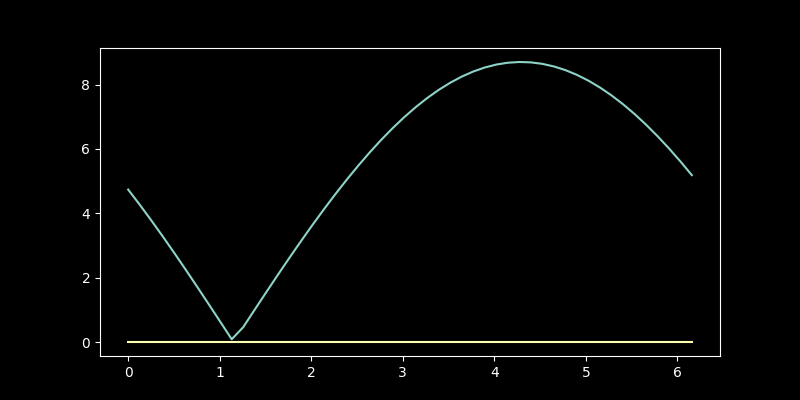

In [268]:
plt.close('all')
fig, ax = plt.subplots(1, figsize=(8,4))
ax.plot(P_leaky_even_theirs.ts,  np.abs(P_leaky_even_theirs.alphas.real));
ax.plot(P_leaky_odd_theirs.ts,  np.abs(P_leaky_odd_theirs.alphas));

In [269]:
P_ls = [P_leaky_even, P_leaky_odd]

full_leaky = lambda x : sum([P.slice_propagate(x) for P in P_ls])
Full_leaky = lambda x, z : sum([P.propagate(x, zs=z) for P in P_ls])

/home/pv/local/slab/slab.py:1499: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=legend_fontsize)


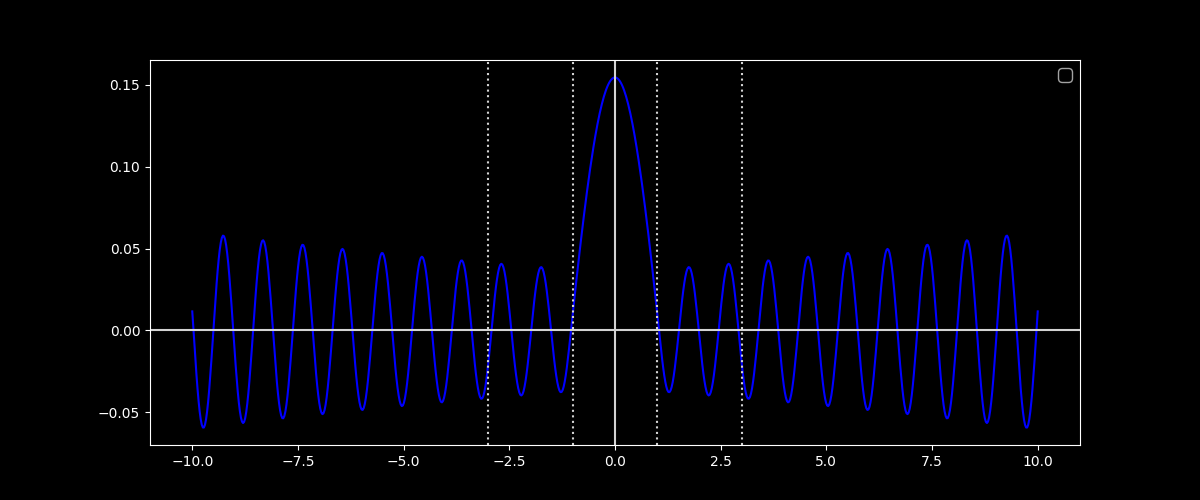

In [270]:
A.plot_field_1d(full_leaky, xs=xs, part='real', color='blue');

#### Asymptotics of true and leaky mode (found with contour integral)



In [271]:
slice_at_x = 0
constant_variable = 'x'

full_z_leaky_ours = lambda z: sum([P.slice_propagate(z, slice_at=slice_at_x, constant_variable=constant_variable) for P in P_ls])
full_z = lambda z: sum([P.slice_propagate(z, slice_at=slice_at_x, constant_variable=constant_variable) for P in Ps])



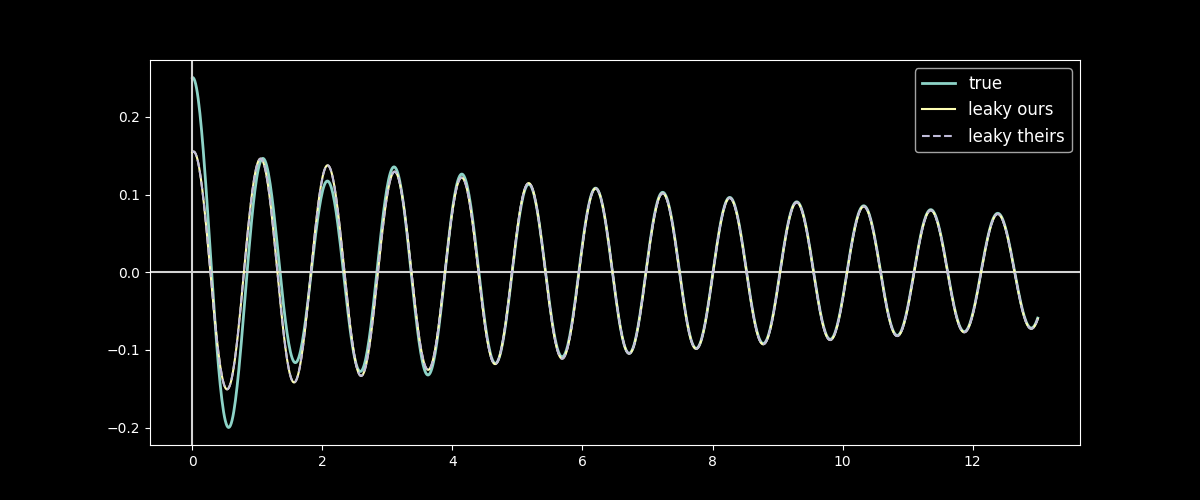

In [275]:
part = 'real'
A.plot_field_1d(full_z, xs=np.linspace(0, 13, 1000), part=part, plot_Rhos=False, linewidth=2,label='true');
A.add_1d_plot(full_z_leaky_ours, xs=np.linspace(0, 13, 1000), part=part, label='leaky ours');
A.add_1d_plot(full_z_leaky_theirs, xs=np.linspace(0, 13, 1000), part=part, linestyle='--', label='leaky theirs');


#### Issues:

- Using our method, even though there appears to be a pole in the integrand where we need it to be, when we do a circular contour integral it appears to zero out.  Everything should be right, but we get zero...  This happens for all other pole locations too: -Z, Z.conj(), -Z.conj().

- This is strange because when we do this for the delta function input everything works out: we get convergent leaky mode fields.


#### Seem to have found issue: We need to use non-conjugated version of expansion and orthogonality



## Adding steepest descent path contribution

In [313]:
def sdp(x, guide=A):
    K = guide.K0 * guide.n0
    return -(K * x) / np.sqrt(K**2 + x**2)

In [330]:
xmin, xmax= -8, .5
ymin, ymax = -1, 2
xs_sdp = np.linspace(xmin, xmax, 1000)
ys_sdp = sdp(xs_sdp)
msk = np.where((ys_sdp<ymax)*(ys_sdp>ymin))

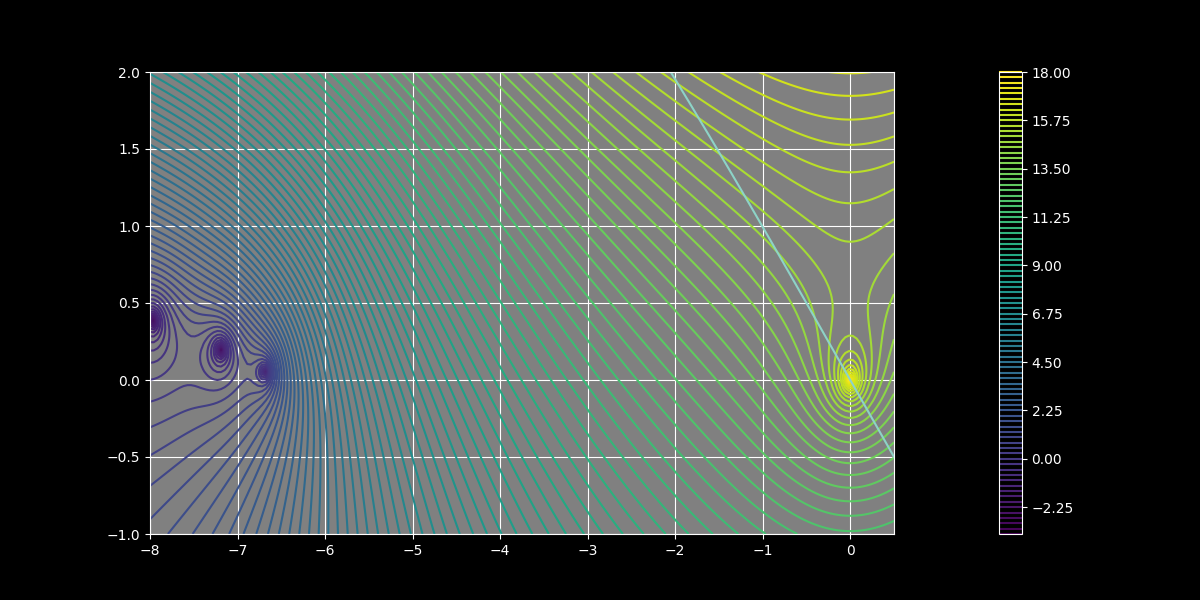

In [332]:
plotlogf(A.determinant_Z, xmin, xmax, ymin, ymax, 'TE', 'leaky', iref=200, rref=200, levels=100)
ax = plt.gca()
ax.plot(xs_sdp[msk], ys_sdp[msk]);
# ax.plot(xs[msk], -ys[msk]);